
##FINANCIAL DATA
MODULE 4 | LESSON 4


---


# **COMPARING LEVERAGED STRATEGIES**

|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** |Option payoffs, Option pricing using Python, Option strategies, P&L concepts, Leverage     |
|**Keywords** |Bull Spread    |


---


*In the previous module, we showed how to get option data imported into Python. This data included not only price, but bid and ask levels, volume and open interest, and implied volatility, among other fields. In this lesson, we compare different ways to enact a bullish trade, using different combinations of stocks, options, and leverage.*

## 1. Importing Real-Time Data

In this lesson, let's get some real-time pricing of stocks and options.

In [1]:
import math

import pandas as pd
import QuantLib as ql
import requests
import yfinance as yf
from yahoo_fin import options

In [2]:
# We can construct a function for communicating with AlphaVantage API using requests


def Alpha_Vantage_data(apikey="demo", endpoint="TIME_SERIES_DAILY", symbol="IBM"):
    # Creating the URL
    url = f"https://www.alphavantage.co/query?function={endpoint}&symbol={symbol}&apikey={apikey}"
    response = requests.get(url)

    # We keep the part of the json that contains the financial data
    data = response.json()["Time Series (Daily)"]

    # Creating a dataframe with datetime as index and converting every input to float (from object with means that all floats were identified as strings)
    df = pd.DataFrame(data).T
    df.index = pd.to_datetime(df.index)
    df = df.astype(float)

    return df

The function described above was developed to demonstrate the feasibility of establishing a connection to an API independently of third-party libraries. It's worth noting that the AlphaVantage API documentation, despite its occasional shortcomings, is the most crucial resource for the development of custom functions.

In [3]:
# You can create an apikey in order to test the free endpoints. If you additionally have a premium key, you will be able to change the endpoint parameter as well.
# If you try to download data whose response is not the same as one assumed in the function, the above function will not work.
# You will need to change it as needed and expand it to accommodate more functionality
IBM = Alpha_Vantage_data()
IBM

,1. open,2. high,3. low,4. close,5. volume
2024-09-10,204.59,205.790,202.870,205.32,3067730.0
2024-09-09,201.94,205.050,201.430,203.53,3705004.0
2024-09-06,202.38,204.100,199.335,200.74,3304491.0
2024-09-05,204.08,205.950,200.960,202.59,3229345.0
2024-09-04,200.76,204.360,200.500,204.11,3111332.0
...,...,...,...,...,...
2024-04-24,183.17,184.290,181.400,184.10,7616643.0
2024-04-23,182.73,184.680,179.000,182.19,5950229.0
2024-04-22,182.45,183.315,180.450,181.90,3076451.0
2024-04-19,182.43,182.800,180.570,181.58,3037990.0


We can use `yfinance` to get NFLX data since the Adjusted Close of NFLX is a premium endpoint of Alpha Vantage.

[*********************100%%**********************]  1 of 1 completed


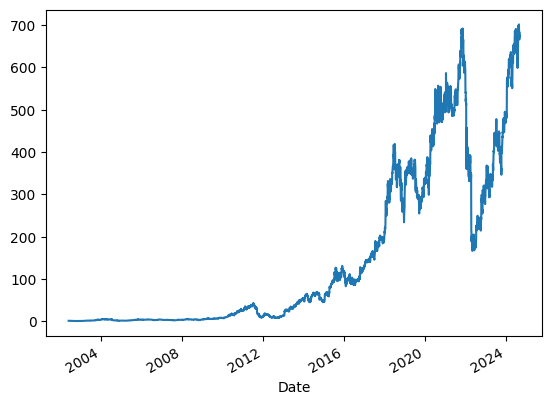

In [4]:
# Alternatively, we can use yfinance since NFLX close is given in its adjusted form.

ts = yf.download("NFLX")["Adj Close"]

ts.plot();

## 2. Overview of Strategies

Suppose we have \$100,000 to invest in a bullish strategy for Netflix.

1. Buy stock using cash.
2. Buy stock on margin.
3. Buy a call option.
4. Buy a bull spread (buy call at K, sell call at K+d).

How much data do we need?
In all cases, we certainly need to know the current stock price, specifically the ask price.
For the cash stock strategies, all we need to know is the current ask price.
For the financed stock strategy, we also need to know the financing rate.
For the option strategies, we need to know the option chain.

## 3. Stock Strategy

First, we'll begin with the stock strategy.
Let's suppose you buy NFLX at 333, and you plan to sell it at 345.

In [5]:
nflx0 = 333
nflx1 = 345

In [6]:
def BuyShares(capital, sharePrice):
    return math.floor(capital / sharePrice)

In [7]:
myCapital = 100000
numShares = BuyShares(myCapital, nflx0)
numShares

300

In [8]:
def CalculatePnL(sellPrice, buyPrice, numShares):
    return round(numShares * (sellPrice - buyPrice), 2)

You can buy 300 shares

In [9]:
cashStockPnL = CalculatePnL(nflx1, nflx0, numShares)
cashStockPnL

3600

You made \$3,600. Let's write a quick function to compute percent return.

In [10]:
def CalculatePctReturn(fundsOut, fundsIn):
    return round(fundsOut / fundsIn * 100, 2)

In [11]:
CalculatePctReturn(cashStockPnL, myCapital)

3.6

The stock increased (345-333)/333 = 3.6%
You bought the stock cash.
Your investment earned 3.6%
This is an example of no leverage.
All the other examples involve some form of leverage.
Consequently, they will have higher returns due to that leverage.

## 4. Financed Stock Strategy

Let's write a short function to calculate functions for buying stocks with borrowed funds.

In [12]:
def FinanceShares(capital, sharePrice, financePct=0.50):
    return BuyShares(capital / financePct, sharePrice)

In [13]:
# We can finance 50% of our purchase.
numLvgShares = FinanceShares(myCapital, nflx0)
lvgPnL = CalculatePnL(nflx1, nflx0, numLvgShares)
lvgPnL

7200

In [14]:
CalculatePctReturn(lvgPnL, myCapital)

7.2

## 5. Call Option Strategy

In [15]:
def option_price_european(
    S0, K, days_to_maturity, r, sigma, call=True, engine="BS", steps=200, paths=10000
):
    """
    This function returns the price of a European Call with 3 different price engines: BS, BT and MC.
    """

    # Setting up the dates
    today = ql.Date().todaysDate()
    maturity = today + days_to_maturity

    # Choosing the type of the option
    if call:
        option_type = ql.Option.Call
    else:
        option_type = ql.Option.Put

    # Creating the payoff
    payoff = ql.PlainVanillaPayoff(option_type, K)

    europeanExercise = ql.EuropeanExercise(maturity)
    europeanOption = ql.VanillaOption(payoff, europeanExercise)

    # Setting up the option's characteristics
    spot = ql.SimpleQuote(S0)
    riskFreeTS = ql.YieldTermStructureHandle(
        ql.FlatForward(today, r, ql.Actual365Fixed())
    )
    volTS = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(today, ql.NullCalendar(), sigma, ql.Actual365Fixed())
    )

    # We will use the analytical way of pricing the options
    process = ql.BlackScholesProcess(ql.QuoteHandle(spot), riskFreeTS, volTS)

    if engine == "BS":
        engine = ql.AnalyticEuropeanEngine(process)
    elif engine == "BT":
        engine = ql.BinomialVanillaEngine(process, "crr", steps)
    elif engine == "MC":
        engine = ql.MCEuropeanEngine(
            process, "PseudoRandom", timeSteps=steps, requiredSamples=paths
        )
    europeanOption.setPricingEngine(engine)

    return europeanOption.NPV()  # NPV stands for Net Present Value

For the call option strategy, we have to select a call and an expiration date.
Clearly, there are many choices.
Suppose we think the stock will increase \$10.

It is prudent to purchase a call that is OTM (strike above the current stock, but not more than \$10; otherwise, it will not be ITM.


In [16]:
nflx_dates = options.get_expiration_dates("nflx")
print(len(nflx_dates))

1


In [17]:
try:
    callsNflx = options.get_calls("nflx")
except:  # noQA E722
    # to load data from local file in case of any disruptions
    callsNflx = pd.read_csv("nflx_calls.csv")

list(callsNflx.columns)

/opt/conda/lib/python3.11/site-packages/yahoo_fin/options.py:42: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(requests.get(site, headers=headers).text)


['Contract Name',
 'Last Trade Date (EDT)',
 'Strike',
 'Last Price',
 'Bid',
 'Ask',
 'Change',
 '% Change',
 'Volume',
 'Open Interest',
 'Implied Volatility']

Let's choose a call option with a strike of 340.

In [18]:
myOption = callsNflx[
    (340 == callsNflx["Strike"])
]  # If there is no option in a specific strike, chose another strike
opt = myOption["Last Price"]
myOption

,Contract Name,Last Trade Date (EDT),Strike,Last Price,Bid,Ask,Change,% Change,Volume,Open Interest,Implied Volatility


In [19]:
nflxOpt1 = round(
    option_price_european(
        S0=333,
        K=340,
        days_to_maturity=4,
        r=0,
        sigma=0.573,
        call=True,
        engine="BS",
        steps=200,
        paths=10000,
    )
    * 100,
    2,
)
nflxOpt1

503.06

In [20]:
# Number of options we can buy
numCallOptions = BuyShares(myCapital, nflxOpt1)
numCallOptions

198

We can buy 198 options; that's a lot of options! Now the stock price jumps to 345. Let's revalue the option at this new price.

In [21]:
nflxOpt2 = round(
    option_price_european(
        S0=345,
        K=340,
        days_to_maturity=4,
        r=0,
        sigma=0.573,
        call=True,
        engine="BS",
        steps=200,
        paths=10000,
    )
    * 100,
    2,
)
nflxOpt2

1093.63

Let's calculate the P&L.

In [22]:
optPnL = CalculatePnL(nflxOpt2, nflxOpt1, numCallOptions)
optPnL

116932.86

Now, calculate the return.

In [23]:
CalculatePctReturn(optPnL, myCapital)

116.93

## 6. Bull Spread Strategy

In this strategy, we buy a call option at 340 and sell one at 350.
Let's price these options.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [24]:
nflxOpt1 = round(
    option_price_european(
        S0=333,
        K=340,
        days_to_maturity=4,
        r=0,
        sigma=0.573,
        call=True,
        engine="BS",
        steps=200,
        paths=10000,
    )
    * 100,
    2,
)

nflxOpt2 = round(
    option_price_european(
        S0=333,
        K=350,
        days_to_maturity=4,
        r=0,
        sigma=0.573,
        call=True,
        engine="BS",
        steps=200,
        paths=10000,
    )
    * 100,
    2,
)

print([nflxOpt1, nflxOpt2])
nflxSpr1 = nflxOpt1 - nflxOpt2

[503.06, 233.33]


In [25]:
nflxOpt2 / 100

2.3333

Let's plot the payoff of the bull strategy.

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Using the seaborn style "Whitegrid"
sns.set_style("whitegrid")

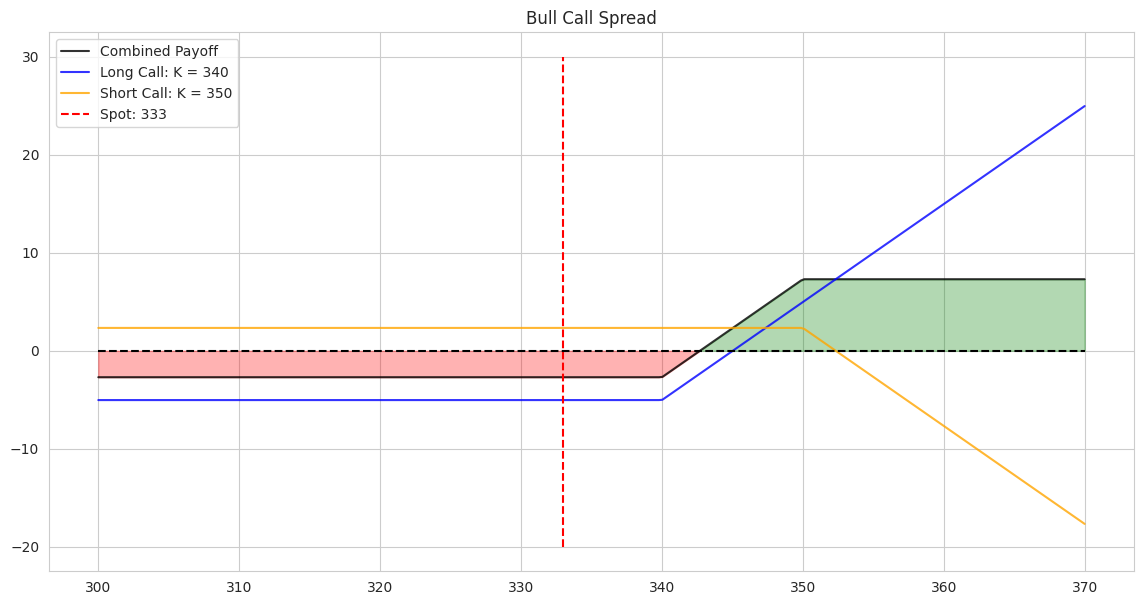

In [27]:
# Plotting the payoff of the bull call spread strategy

stock_prices = np.linspace(300, 370, 300)
call_pnl_1 = np.maximum(stock_prices - 340, 0) - nflxOpt1 / 100
call_pnl_2 = -(np.maximum(stock_prices - 350, 0) - nflxOpt2 / 100)
combined_pnl = call_pnl_1 + call_pnl_2

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)

ax.fill_between(
    stock_prices, combined_pnl, where=(combined_pnl < 0), color="red", alpha=0.3
)
ax.fill_between(
    stock_prices, combined_pnl, where=(combined_pnl > 0), color="green", alpha=0.3
)
ax.plot(stock_prices, combined_pnl, color="black", alpha=0.8, label="Combined Payoff")
ax.plot(stock_prices, call_pnl_1, color="blue", alpha=0.8, label="Long Call: K = 340")
ax.plot(
    stock_prices, call_pnl_2, color="orange", alpha=0.8, label="Short Call: K = 350"
)
ax.vlines(x=333, ymin=-20, ymax=30, linestyle="--", color="red", label="Spot: 333")
ax.hlines(y=0, xmin=300, xmax=370, linestyle="--", color="black")
ax.set_title("Bull Call Spread")
ax.legend()
plt.show()

For each call option we buy, we need to sell one.
The sale creates \\$233.33 per contract.
The purchase costs \\$503.06 per contract.
Therefore, the net price is \\$269.73.
The bull spread costs a little more than half the amount that the regular call option costs. This is because we are "rebated" by selling a call that is further OTM.

In [28]:
# Number of spread options
nflxOptB = nflxOpt1 - nflxOpt2
numSpreadOptions = BuyShares(myCapital, nflxOptB)
numSpreadOptions

370

In [29]:
nflxOpt3 = round(
    option_price_european(
        S0=345,
        K=340,
        days_to_maturity=4,
        r=0,
        sigma=0.573,
        call=True,
        engine="BS",
        steps=200,
        paths=10000,
    )
    * 100,
    2,
)

nflxOpt4 = round(
    option_price_european(
        S0=345,
        K=350,
        days_to_maturity=4,
        r=0,
        sigma=0.573,
        call=True,
        engine="BS",
        steps=200,
        paths=10000,
    )
    * 100,
    2,
)

print([nflxOpt3, nflxOpt4])
nflxSpr2 = nflxOpt3 - nflxOpt4

[1093.63, 605.25]


In [30]:
sprPnL = CalculatePnL(nflxSpr2, nflxSpr1, numSpreadOptions)
sprPnL

80900.5

In [31]:
CalculatePctReturn(sprPnL, myCapital)

80.9

## 7. Leverage

Stock              3.6%  </br>
Financed Stock     7.2%  </br>
Call Option       116.94%  </br>
Bull Spread       80.9%   </br>

Keep in mind that these options expire in four days.
If the price does not move that much in a short time, we stand to lose 100% of the option investment. This is extremely risky.
Of course, we could find options that have more time to expiration, which
would be more expensive to buy but less risky since the extra time allows more volatility to take place.

Nevertheless, the results are evident.
The most leveraged position is the call option: It has the highest return.
Options have built-in leverage because they control 100 shares of stock.

The next most leveraged position is the bull spread: It has a long call option but is hedged by selling another call option. This limits the upside but is cheaper than merely buying the call option.

The next most leveraged position is using the underlying. Borrowing money to buy assets is a different type of leverage; rather than through a multiplier, it is simply through the fact that the invested funds should earn a higher rate of return than the borrowed funds.

The unleveraged position is simply trading the underlying without any financing. Leveraged returns attract institutional money for the potential of greater returns. Looking at data, such as the put call open interest ratio, tells us how the option traders are behaving through market data.

There is much more data than just prices and returns. When you use derivatives, there are extraordinary amounts of data that indicate both sentiment and fear in the market. In future courses, we'll examine these in more detail, especially when we study implied volatility.


## 8. Conclusion

In this lesson, we compared different ways to enact a bullish trade, using different combinations of stocks, options, and leverage. Leverage can work through borrowed funds or through a derivative controlling a multitude of underlying assets. In the next module, we expand our knowledge of Python to areas of securitization and credit.

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
